# [LAB 06] 데이터 시각화 - 10. Stacked Bar Plot (누적 막대 그래프)

## #01.준비작업 

### 1. 패키지 참조 

In [1]:
from jussam import load_data
from helpers import *
from pandas import pivot_table
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기 

In [2]:
origin = load_data("region_jobs")
origin

📚 지역별 산업 종사자 수를 조사한 가상의 데이터


,지역,산업,종사자 수
0,서울,서비스업,520
1,부산,서비스업,340
2,대구,서비스업,280
3,인천,서비스업,310
4,서울,제조업,180
5,부산,제조업,220
6,대구,제조업,160
7,인천,제조업,140
8,서울,IT산업,260
9,부산,IT산업,110


### 3. 데이터 전처리 

In [3]:
## 데이터 피벗팅 ( fill_value=0 --> 결측치를 0으로 채움) 
df = pivot_table(origin, index="지역", columns="산업", 
                 values="종사자 수", aggfunc=np.sum, fill_value=0)

# 인덱스를 문자열 카테고리로 반환 
df.index = df.index.astype('str').astype('category')

df

산업,IT산업,서비스업,제조업
지역,,,
대구,90,280,160
부산,110,340,220
서울,260,520,180
인천,150,310,140


## #02. 절대값 누적 막대 그래프 

### 1. step1 - 기본 막대 그래프 생성 

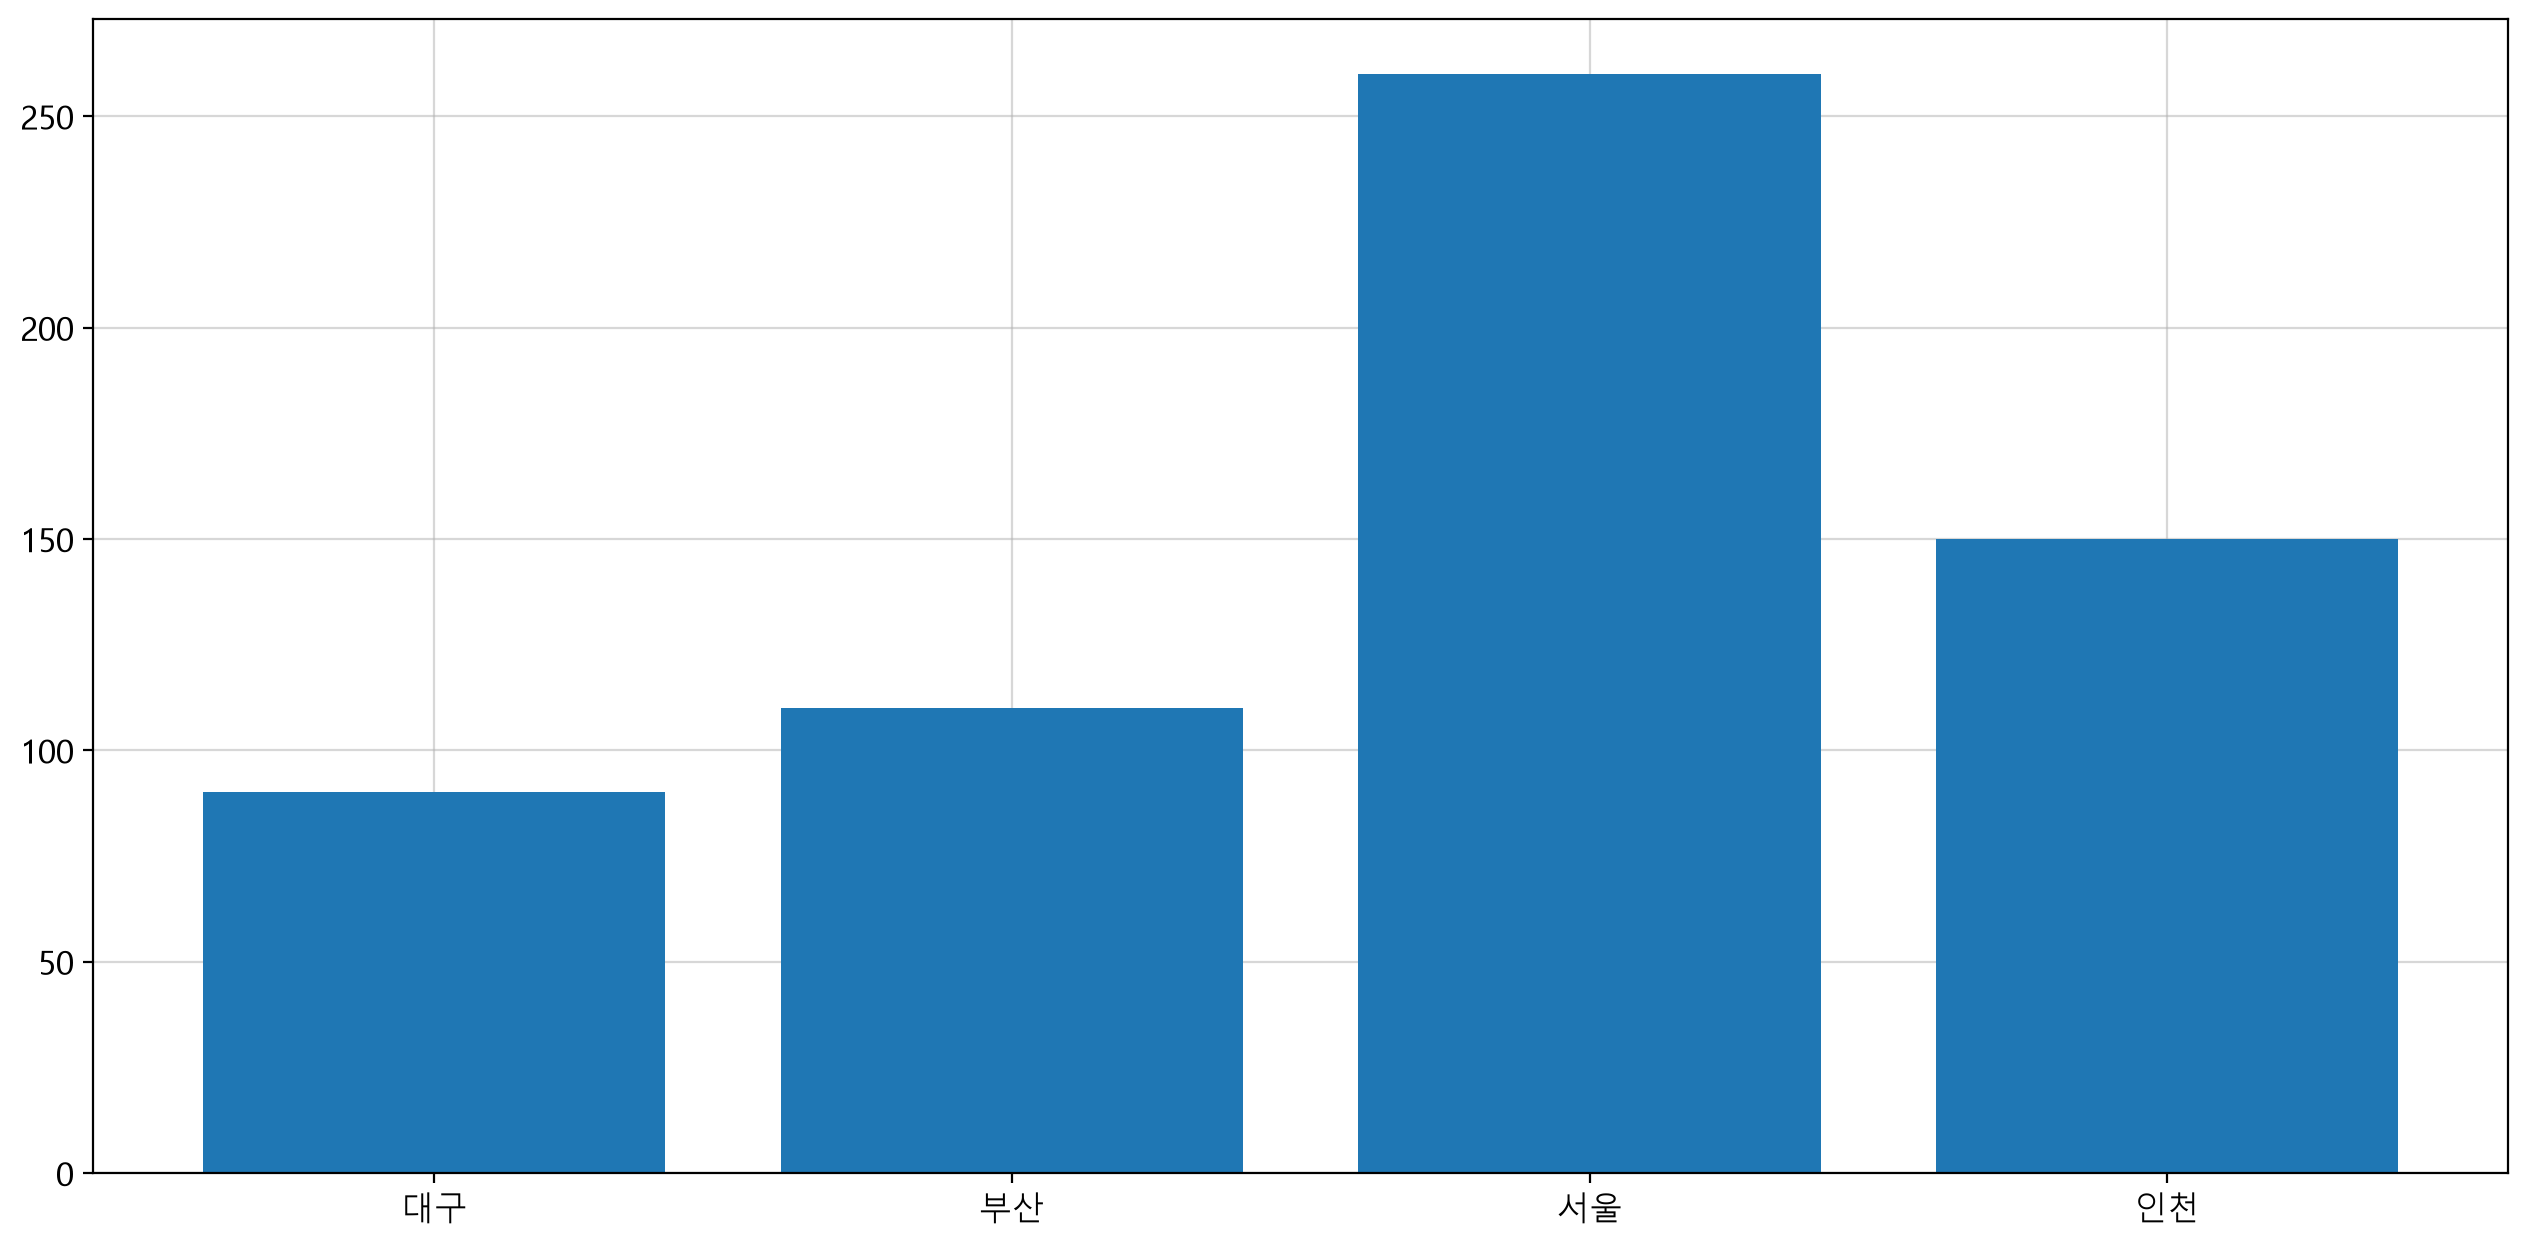

In [4]:
fig, ax = my_plot.init()

# 지역별 IT 산업 종사자 수에 대한 기본 막대 그래프 
ax.bar(df.index, df['IT산업'])

my_plot.show()

### 2.step2 - 막대 그래프 위에 새로운 데이터 쌓기 

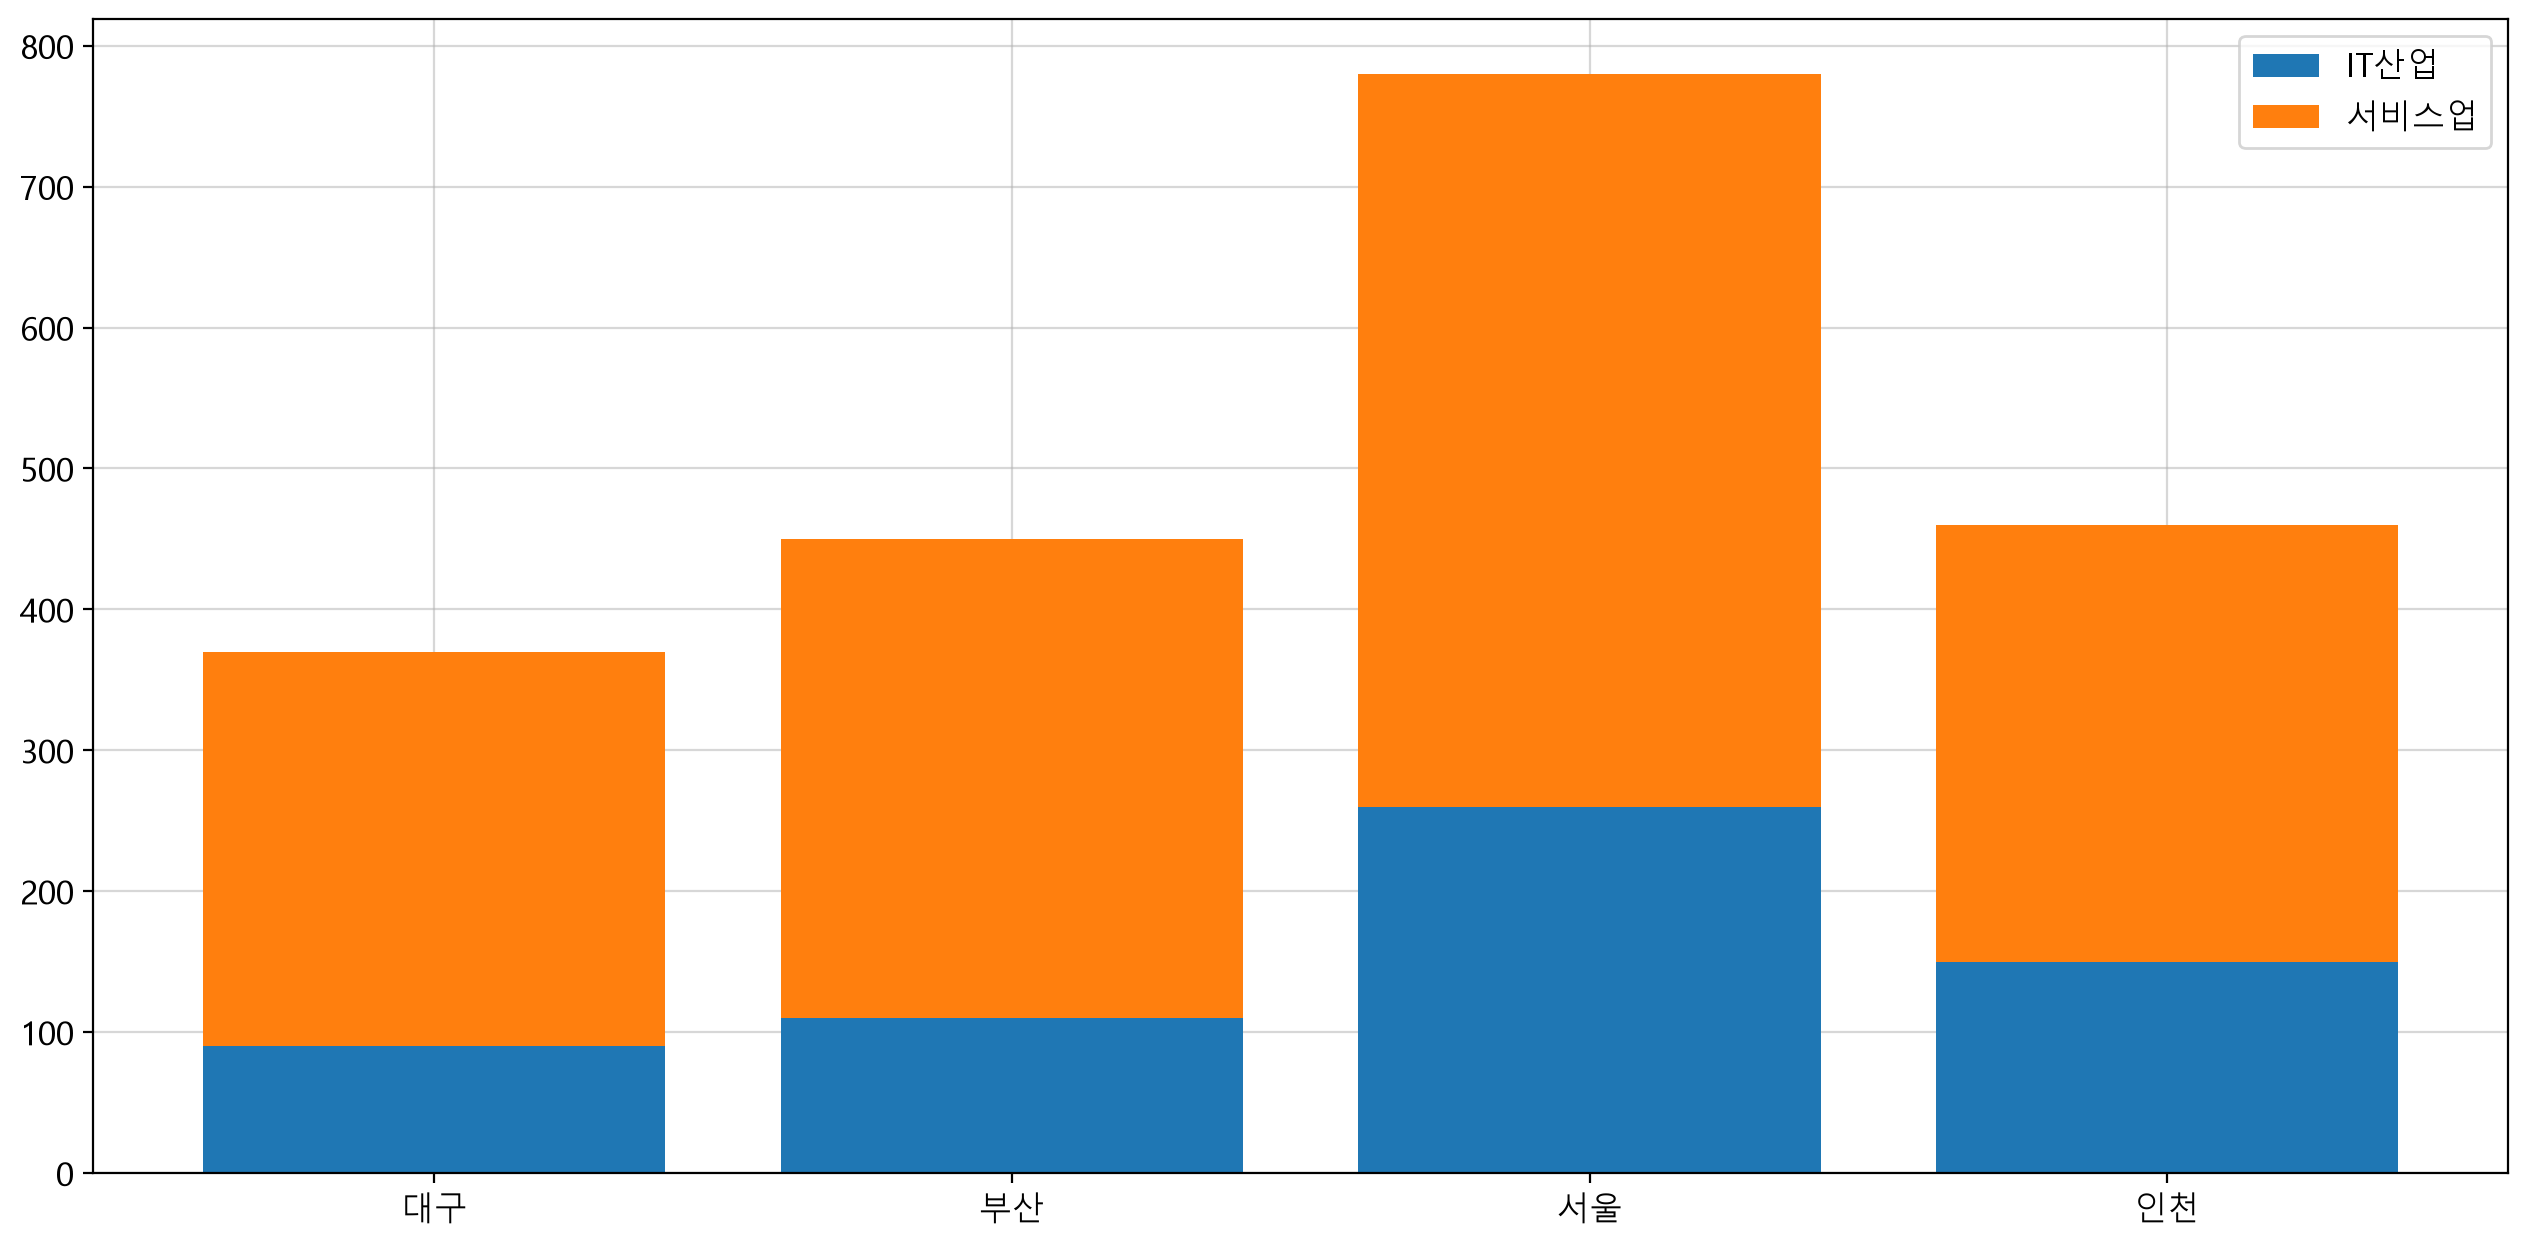

In [5]:
fig, ax = my_plot.init()

# 지역별 IT 산업 종사자 수에 대한 기본 막대 그래프 
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시 
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 기본 막대 그래프와 누적 막대 그래프에 대한 범례 추가 
# --> bbox_to_anchor= (1,1) : 범주의 위치 오른쪽(1) 상단(1)
# --> bbox_to_anchor= (0,0) : 범주 위치 왼쪽(0) 하단(0)
ax.legend(bbox_to_anchor=(1,1))

my_plot.show()

### 3. step3 - 추가 데이터 쌓기 

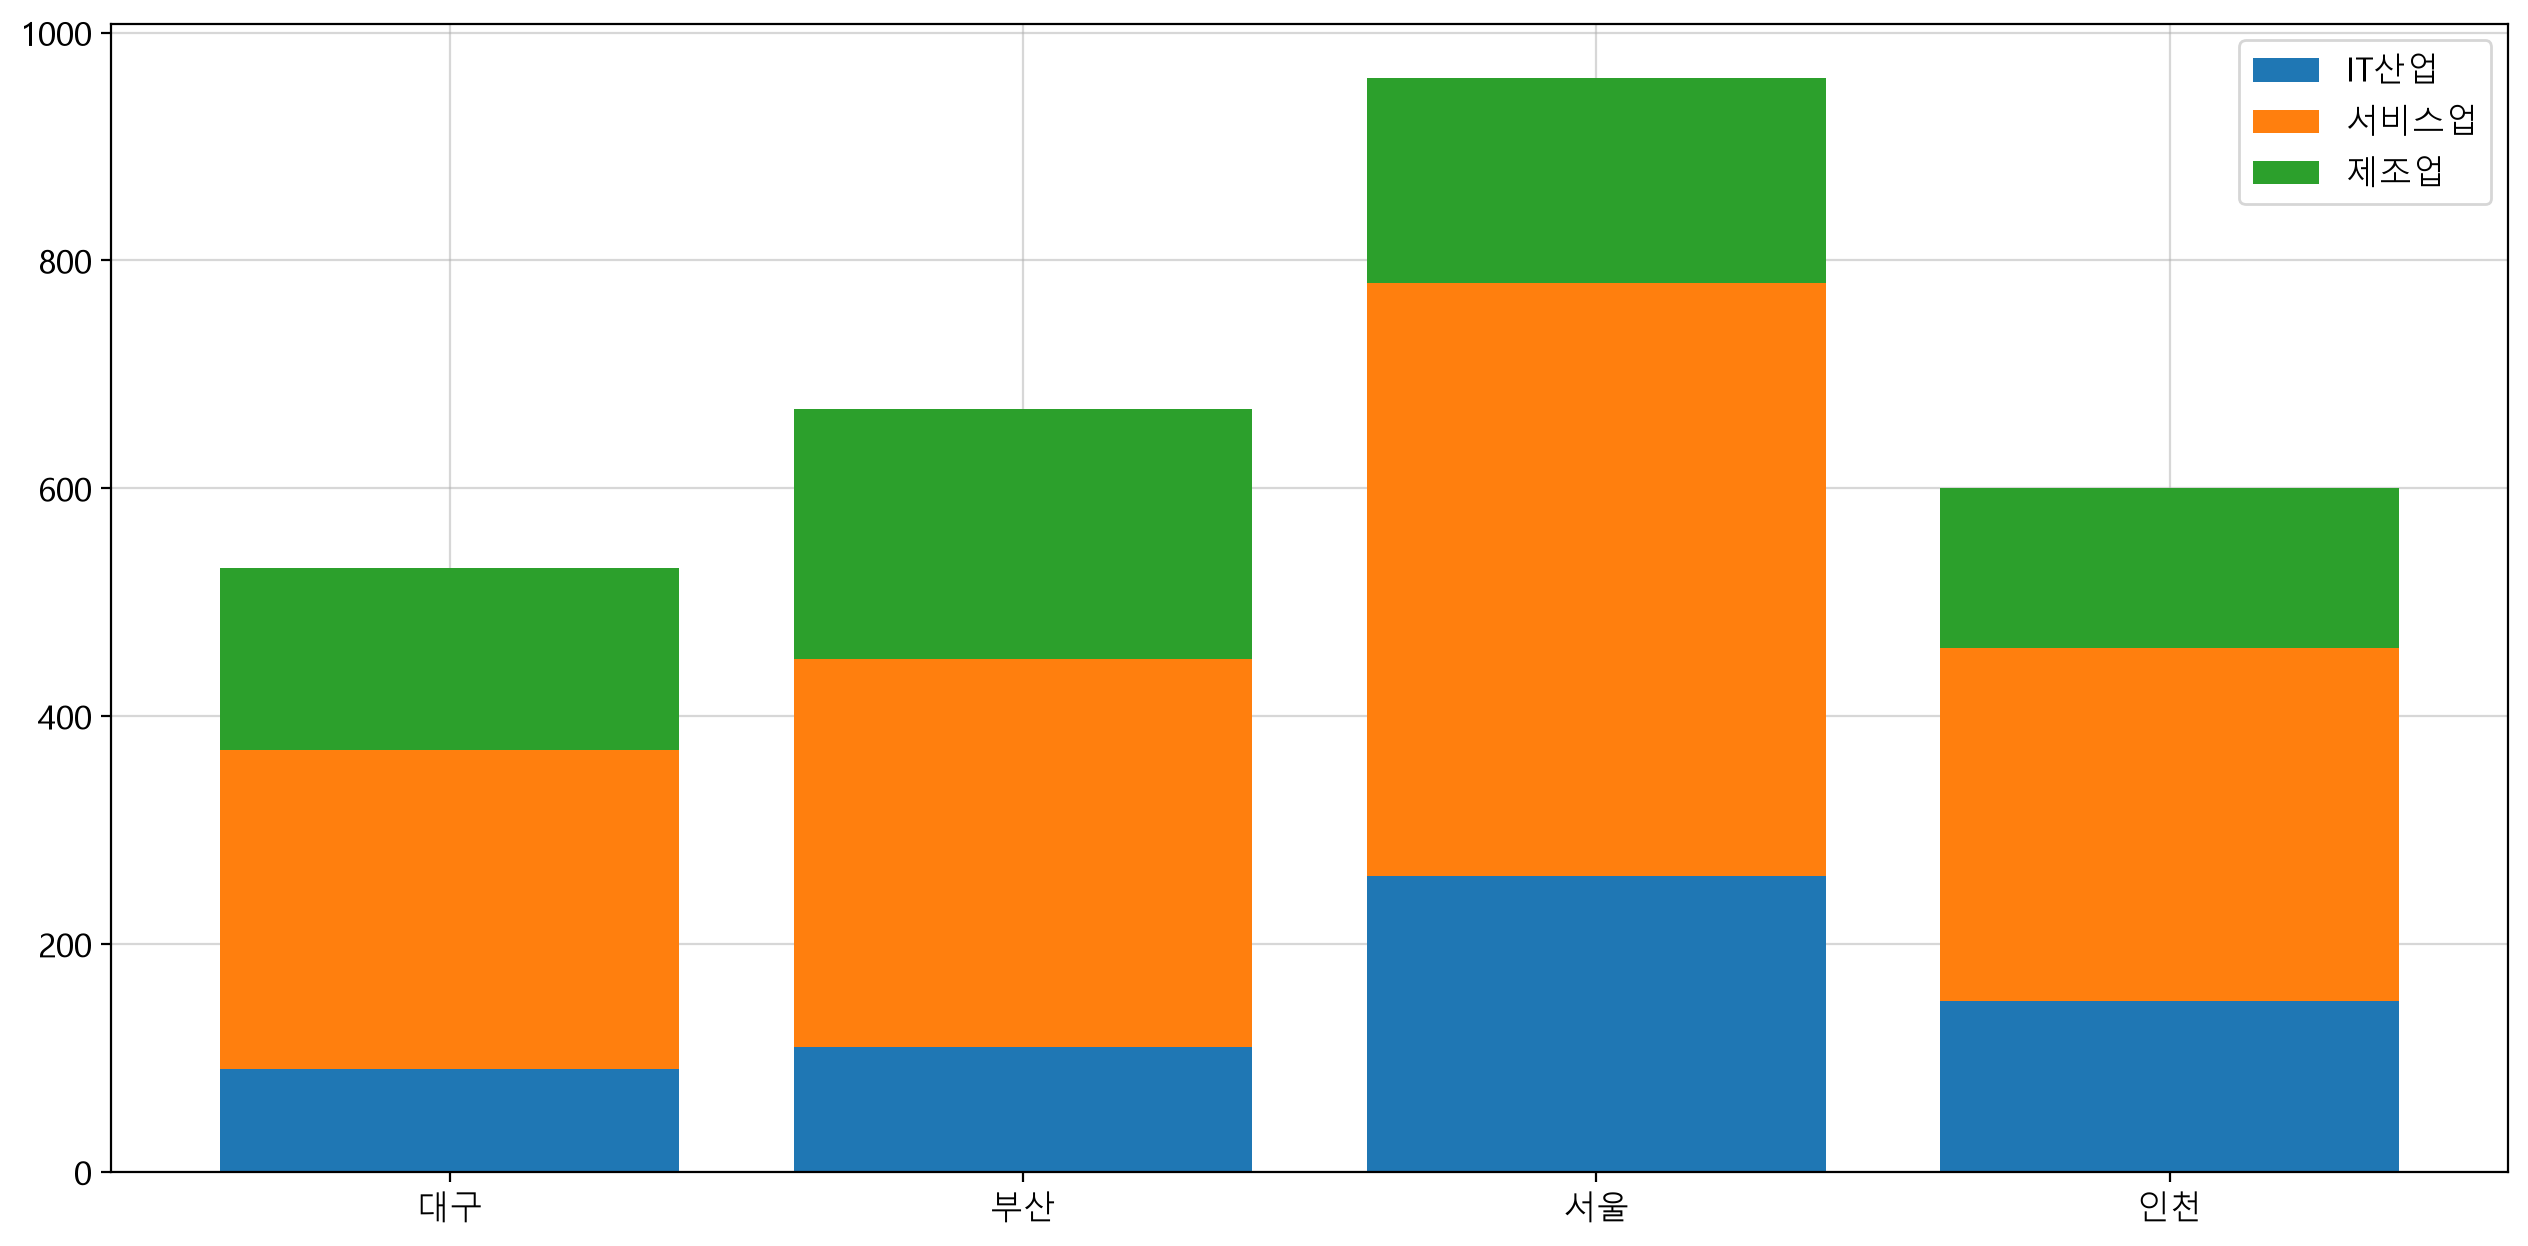

In [6]:
fig, ax = my_plot.init()

# 지역별 IT 산업 종사자 수에 대한 기본 막대 그래프 
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시 
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.bar(df.index, df['제조업'], bottom=df['IT산업']+df['서비스업'], label='제조업')

# 기본 막대 그래프와 누적 막대 그래프에 대한 범례 추가 
# --> bbox_to_anchor= (1,1) : 범주의 위치 오른쪽(1) 상단(1)
# --> bbox_to_anchor= (0,0) : 범주 위치 왼쪽(0) 하단(0)
ax.legend(bbox_to_anchor=(1,1))

my_plot.show()

### 4. step4 - 각 영역 안에 수치값 표시하기 

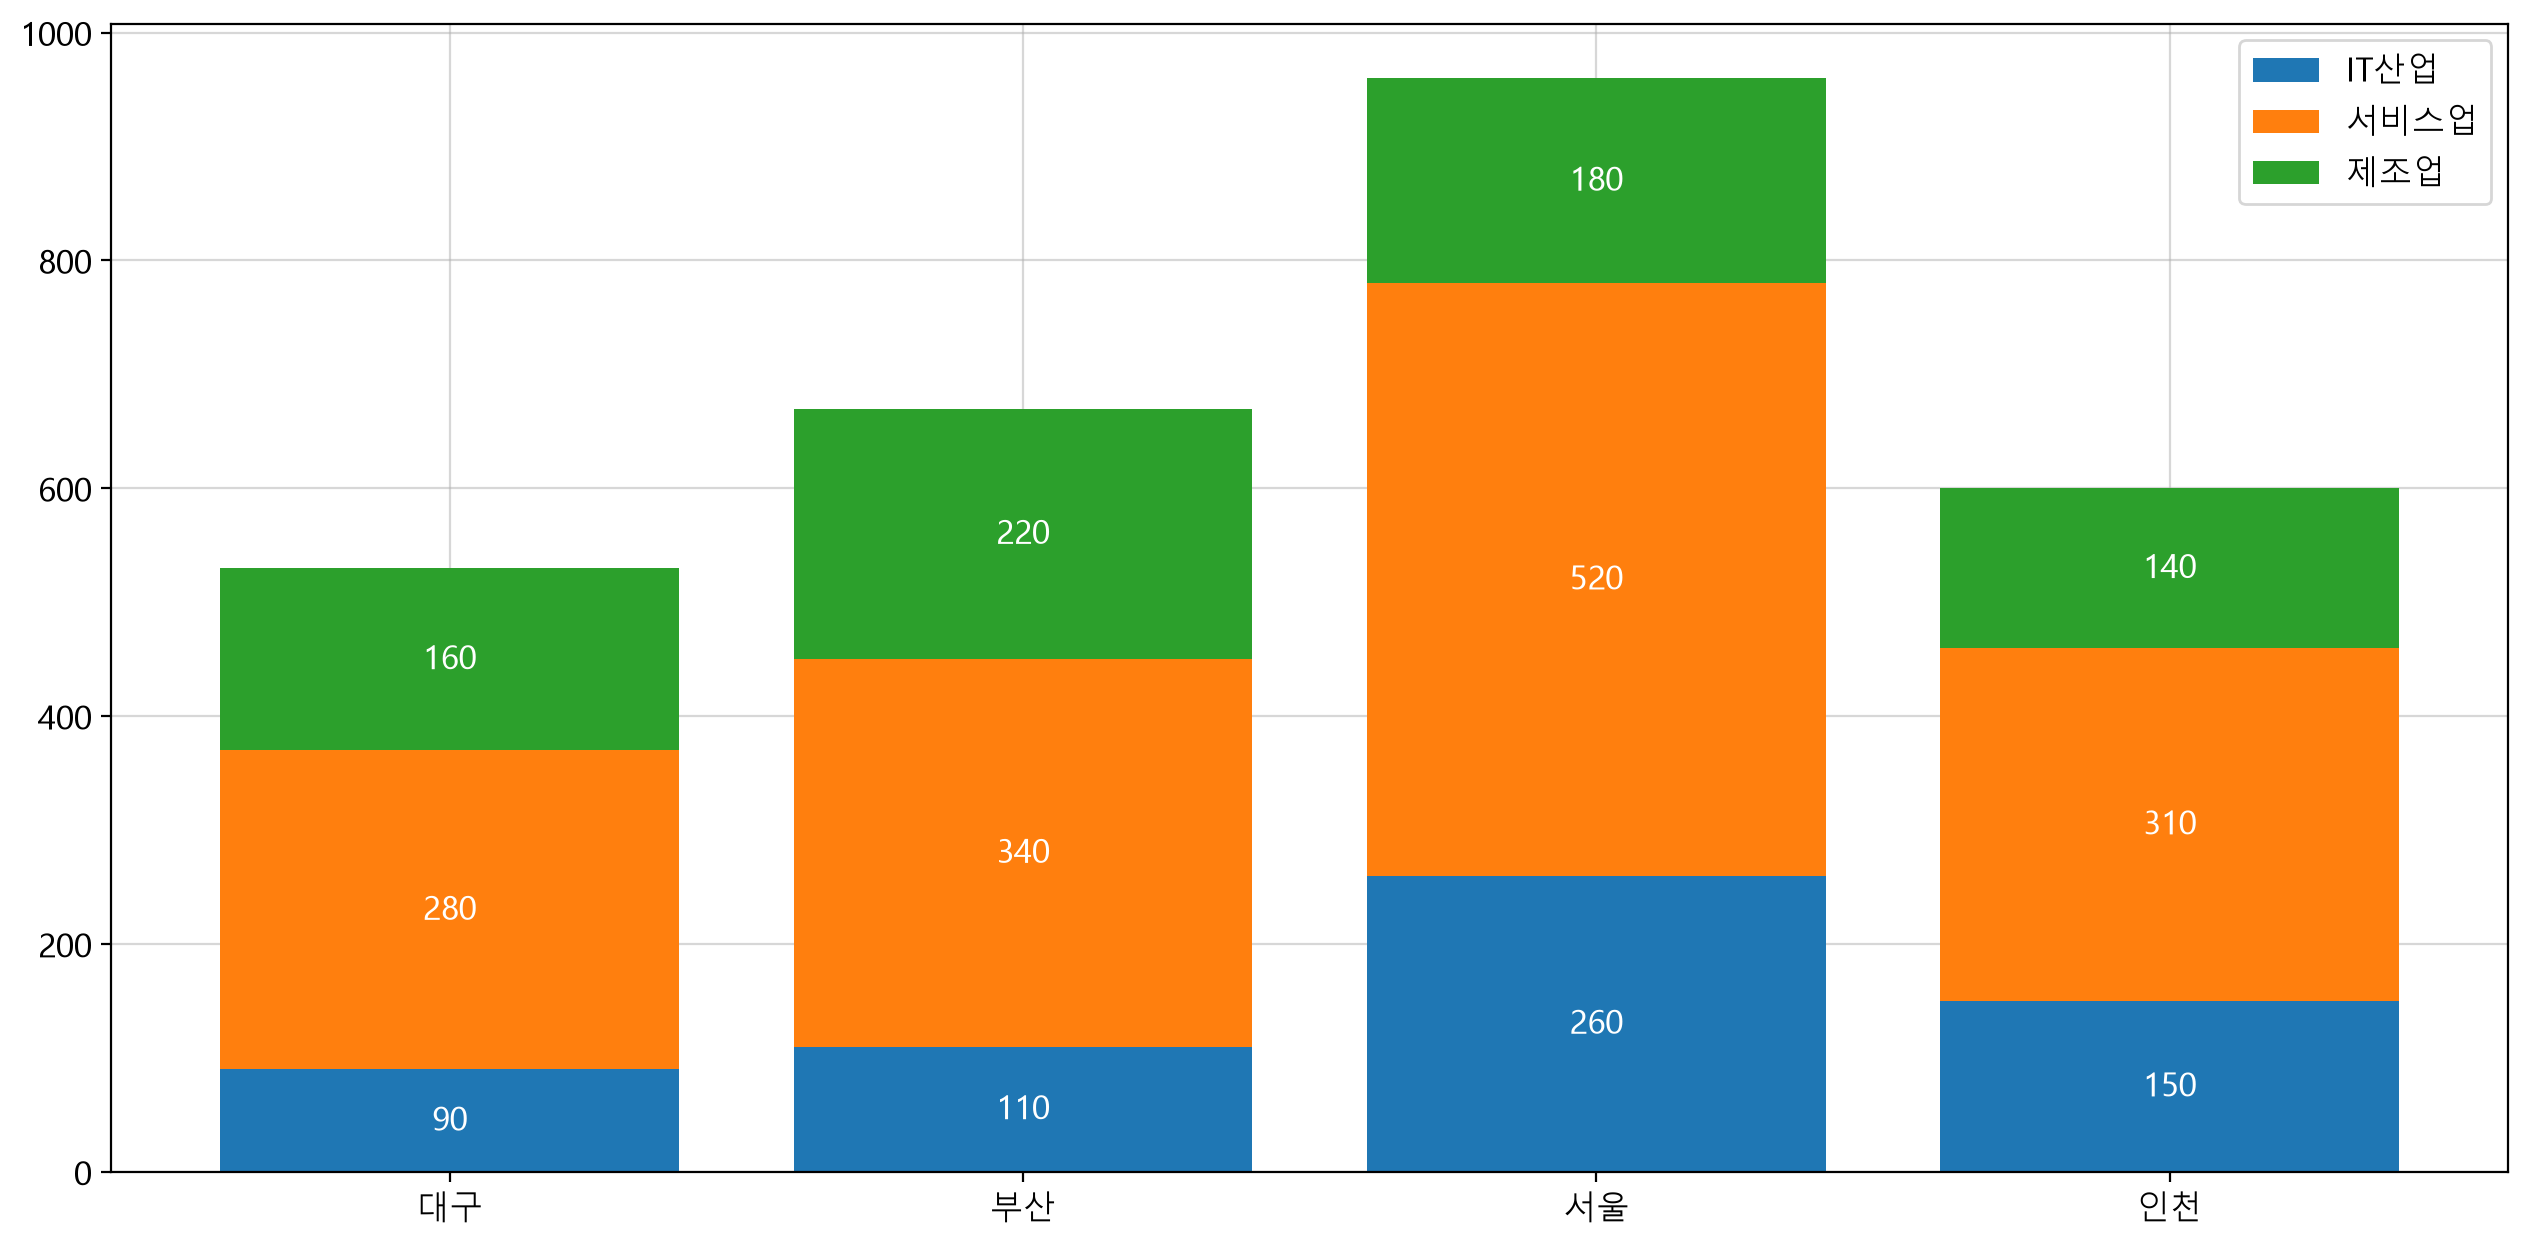

In [7]:
fig, ax = my_plot.init()

# 지역별 IT 산업 종사자 수에 대한 기본 막대 그래프 
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시 
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.bar(df.index, df['제조업'], bottom=df['IT산업']+df['서비스업'], label='제조업')

# 기본 막대 그래프와 누적 막대 그래프에 대한 범례 추가 
# --> bbox_to_anchor= (1,1) : 범주의 위치 오른쪽(1) 상단(1)
# --> bbox_to_anchor= (0,0) : 범주 위치 왼쪽(0) 하단(0)
ax.legend(bbox_to_anchor=(1,1))

# 각 막대 위에 종사자 수 표시 
for i in df.index : 
    ax.text(x=i, y=df['IT산업'][i]/2, s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i]/2, s=str(df['서비스업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i] + df['제조업'][i]/2 , s=str(df['제조업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
 
my_plot.show()

## #03. 색상 팔레트 적용하기 

### 1. seaborn의 팔레트에서 범주의 종류 수 만큼 색상 추출 

In [8]:
# seaborn 의 pastel color palette 사용 
colors = sb.color_palette("Set2", 3)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549)]

### 2. 색상을 적용한 가로 누적 막대 그래프 (1/2)

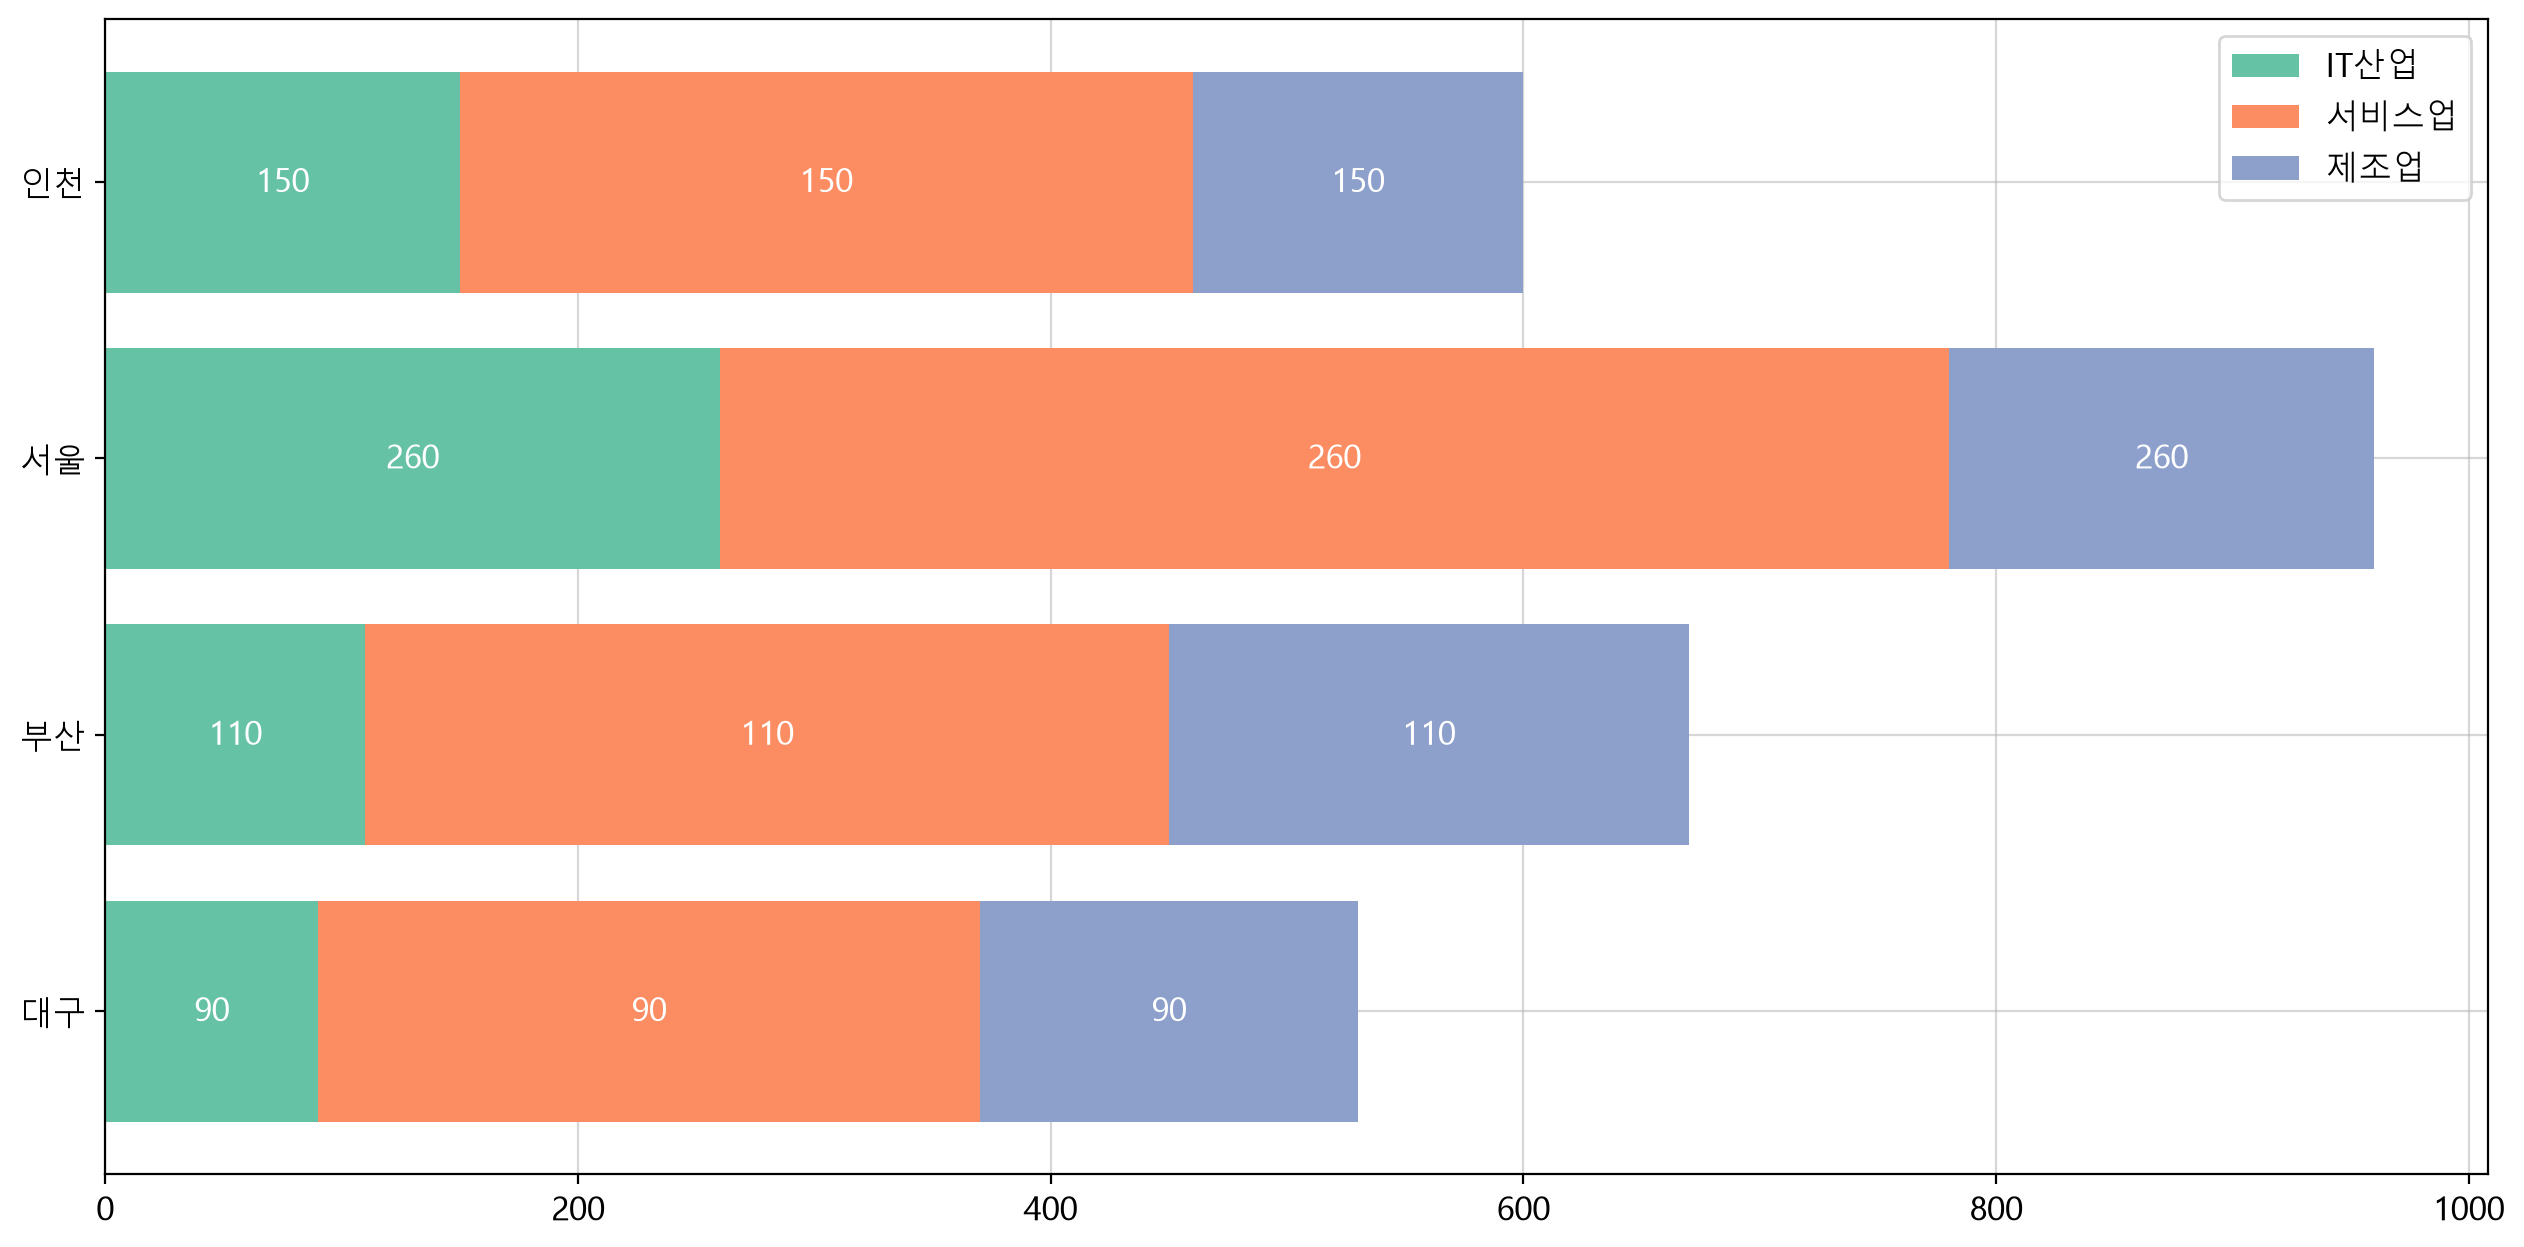

In [9]:
fig, ax = my_plot.init()

# 지역별 IT 산업 종사자 수에 대한 기본 막대 그래프 
ax.barh(df.index, df['IT산업'], label='IT산업', color=colors[0])

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시 
ax.barh(df.index, df['서비스업'], left=df['IT산업'], label='서비스업', color=colors[1])

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.barh(df.index, df['제조업'], left=df['IT산업']+df['서비스업'], label='제조업',
        color=colors[2])

# 기본 막대 그래프와 누적 막대 그래프에 대한 범례 추가 
# --> bbox_to_anchor= (1,1) : 범주의 위치 오른쪽(1) 상단(1)
# --> bbox_to_anchor= (0,0) : 범주 위치 왼쪽(0) 하단(0)
ax.legend(bbox_to_anchor=(1,1))

# 각 막대 위에 종사자 수 표시 
for i in df.index: 
    ax.text(x=df['IT산업'][i]/2, y=i, 
            s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12
            )
    ax.text(x=df['IT산업'][i] + df['서비스업'][i]/2, y=i, 
            s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12
            ) 
    ax.text(x=df['IT산업'][i] +df['서비스업'][i]+ df['제조업'][i]/2 , y=i, 
            s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12
            )       
my_plot.show()

## #04. 모듈화 기능 확인 

findfont: Failed to find font weight 500, now using 400.


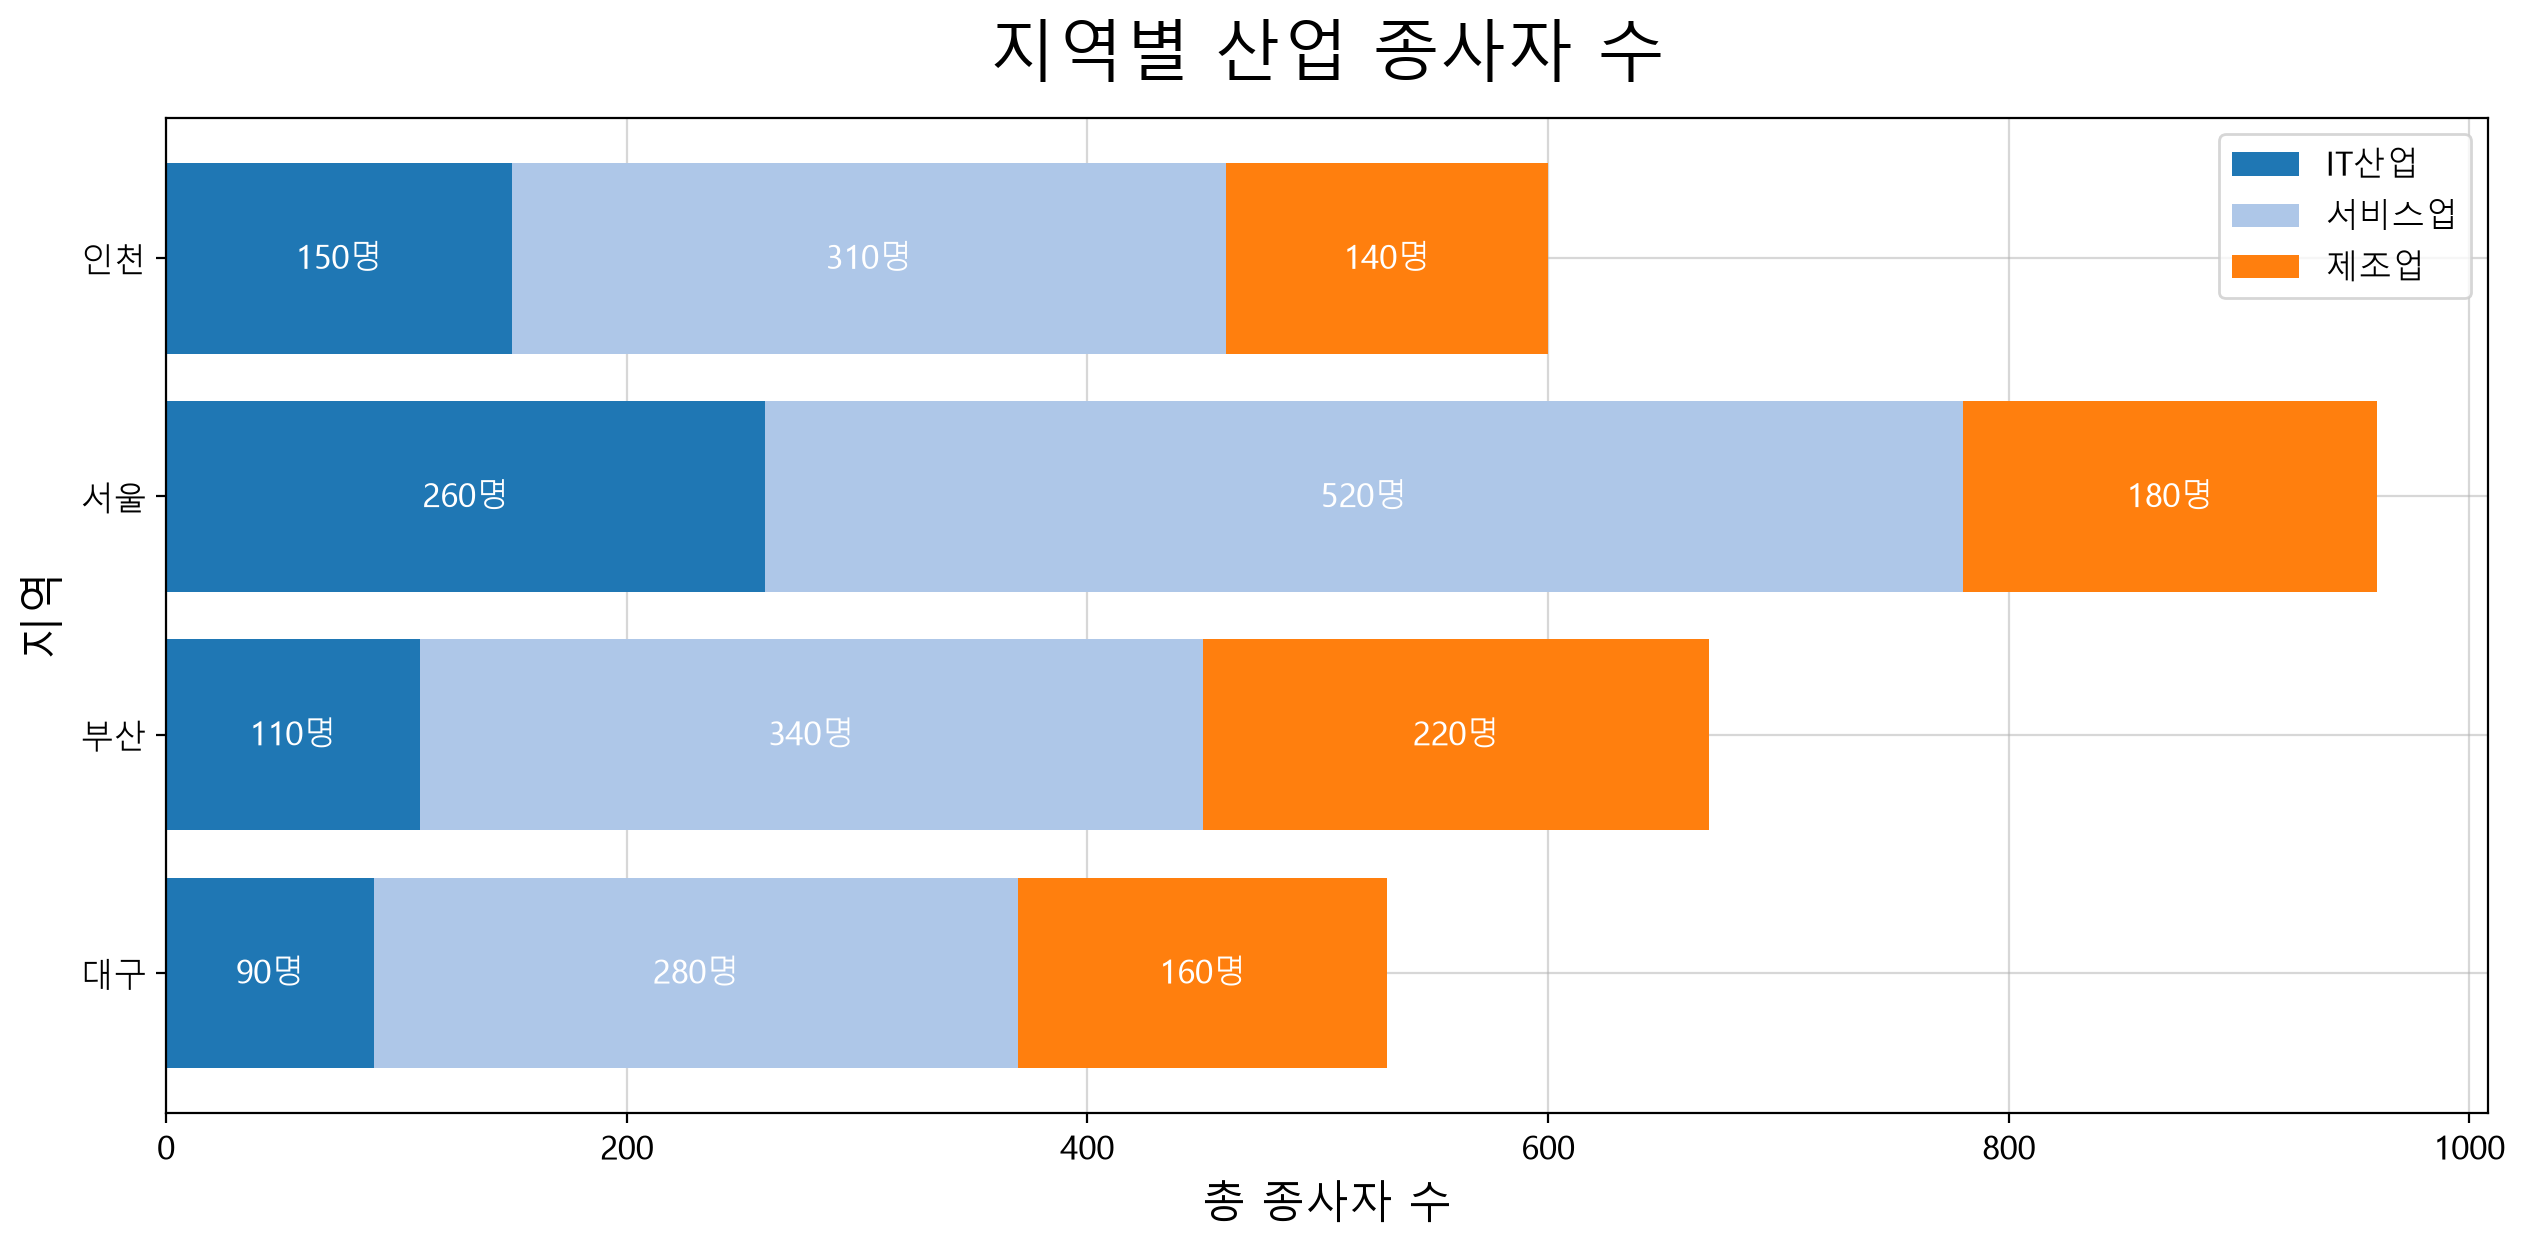

In [10]:
my_plot.stackplot(data=origin, # 데이터 프레임
                  x = "지역",   # x축에 사용할 열 이름 
                  y = "종사자 수", # y축에 사용할 행 이름 
                  hue= "산업", # 누적 막대 그래프의 범주형 열 이름 
                  aggfunc=np.sum, # 집계함수 ( 기본값 : np.sum)
                  orient='h', # 그래프 방향 ('v' -> 수직, 'h' -> 수평)
                  text_format="{:d}명", # 텍스트 포멧 (기본값 : "{:.1f}")
                  palette = "tab20", # 색상 팔레트 (기본값 : None)
                  title="지역별 산업 종사자 수", # 그래프 제목 (기본값: None)
                  xlabel="총 종사자 수", # x축 레이블 (기본값: None)
                  ylabel="지역", # y축 레이블 (기본값: None)
                  )

## #01. 연습문제 - 다이아몬드 컷팅 등급별 색상의 가격 평균 비교

In [ ]:
# color D의 평균 가격이 가장 높게 나타나는 cut 등급

In [11]:
from jussam import load_data
from helpers import *
from pandas import pivot_table
import seaborn as sb
import numpy as np


In [12]:
###  데이터셋 불러오기 
origin = load_data("diamonds_qtcheck")
origin

📚 다이아몬드 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)



,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000
...,...,...,...,...,...,...,...,...,...,...
53789,2757,0.720,Ideal,D,SI1,5.750,5.760,3.500,60.800,57.000
53790,2757,0.720,Good,D,SI1,5.690,5.750,3.610,63.100,55.000
53791,2757,0.700,Very Good,D,SI1,5.660,5.680,3.560,62.800,60.000
53792,2757,0.860,Premium,H,SI2,6.150,6.120,3.740,61.000,58.000


In [13]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   depth    53794 non-null  float64 
 9   table    53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [ ]:
# 등급별 평균 가격 막대 그래프 

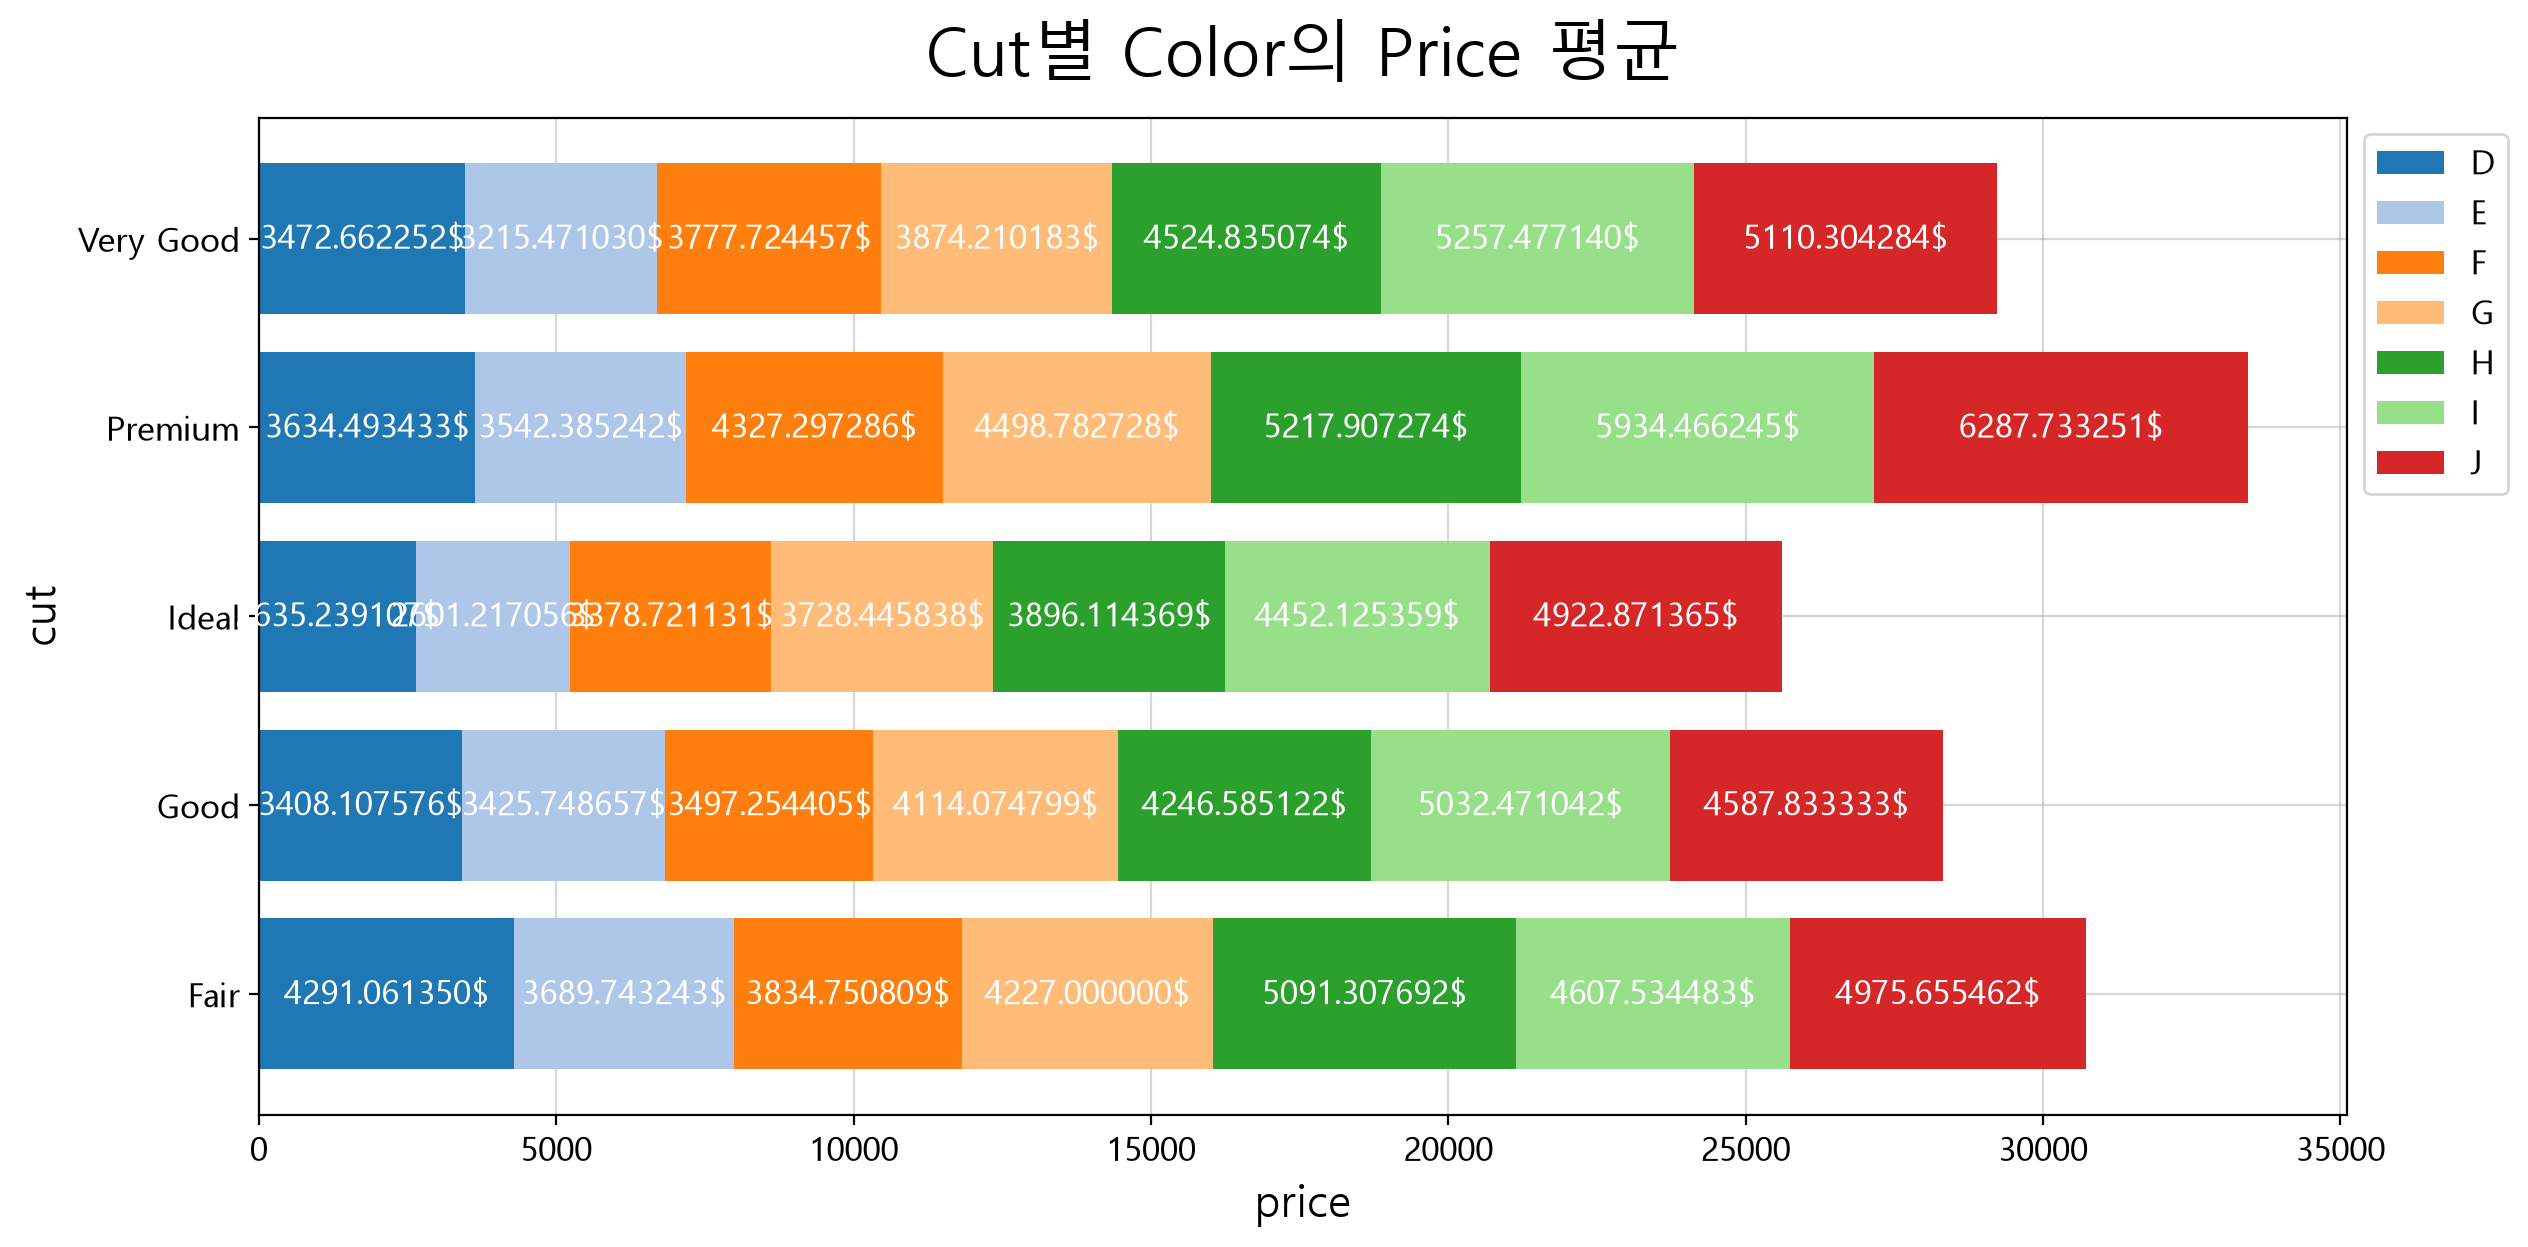

In [18]:
my_plot.stackplot(data=origin, # 데이터 프레임
                  x = "cut",   # x축에 사용할 열 이름 
                  y = "price", # y축에 사용할 행 이름 
                  hue= "color", # 누적 막대 그래프의 범주형 열 이름 
                  aggfunc=np.mean, # 집계함수 ( 기본값 : np.sum)
                  orient='h', # 그래프 방향 ('v' -> 수직, 'h' -> 수평)
                  text_format="{:f}$", # 텍스트 포멧 (기본값 : "{:.1f}")
                  palette = "tab20", # 색상 팔레트 (기본값 : None)
                  title="Cut별 Color의 Price 평균", # 그래프 제목 (기본값: None)
                  xlabel="price", # x축 레이블 (기본값: None)
                  ylabel="cut", # y축 레이블 (기본값: None)
                  )

Color D(가장 좋은 색상 등급)의 평균 가격이 가장 높게 나타나는 Cut 등급은?

- **정답**: Fair



5개 Cut 등급 중 4개에서는 J 또는 I Color가 가장 높은 평균 가격을 보이지만, 유일하게 다른 Color 등급이 1위를 차지하는 Cut이 존재한다. 해당 Cut 등급에서 평균 가격이 가장 높은 Color는?

- **정답**: H

대부분의 Color 등급에서는 Ideal Cut의 평균 가격이 가장 낮지만, J Color에서는 Ideal보다 평균 가격이 더 낮은 Cut 등급이 존재한다. 해당 Cut 등급은?

- **정답**: Good